In [1]:
import h5py
import sys
sys.path.append("/eos/user/v/vgousyle/")
from WCTE_event_display.EventDisplay import EventDisplay
import matplotlib.colors as colors

In [3]:
#import numpy as np
proton_mass=938
mom=1500
c = 299_792_458
E_tot=np.sqrt(proton_mass**2+float((mom)**2))
print(E_tot)
e_beam=E_tot-proton_mass
print(e_beam)

1769.13651253938
831.13651253938


In [2]:
import h5py
import sys
sys.path.append("/eos/user/v/vgousyle/")
from WCTE_event_display.EventDisplay import EventDisplay
import matplotlib.colors as colors
import sys
sys.path.append("/eos/user/v/vgousyle/proton_search/Geometry/")
#sys.path.insert(0, "../../Geometry")
from Geometry.Device import Device
import awkward as ak
sys.path.append("/eos/user/v/vgousyle/proton_search/TimeCal/")
from TimeCal.TC_Multilaterator import TC_Multilaterator
from TimeCal.TC_BeaconData import TC_BeaconData
import numpy as np

In [3]:
cols = ["trigger_times","trigger_types","window_time",
        "hit_mpmt_card_ids","hit_mpmt_slot_ids","hit_pmt_channel_ids",
        "hit_pmt_position_ids","hit_pmt_times","hit_pmt_calibrated_times",
        "hit_pmt_charges","hit_pmt_readout_mask","window_data_quality","beam_pid",'t0_time']

# define dictionary to store them all
all_events = {}
#1610
particle_list=['muon']
for particle in particle_list:
    fname = f"/eos/user/v/vgousyle/proton_search/analysis_tools/notebooks/Beam_PID_R1610.parquet"#"/eos/user/v/vgousyle/proton_search/Beam_PID_R1567.parquet"#f"/eos/user/v/vgousyle/proton_search/analysis_tools/notebooks/Beam_PID_R{run_number}.parquet"
    
    try:
        # Read all events first
        df = ak.from_parquet(fname, columns=cols)
        #print(particle)
        # Filter to only keep the particle type you want
        mask = df["beam_pid"] == particle  # Filter for muons only
        df_filtered = df[mask]
        print(f"Found {len(df_filtered)} {particle} events")
        all_events[particle] = df_filtered
        
    except Exception as e:
        print(f"Error reading {particle}: {e}")
all_proton_events = all_events.get(particle_list[0], ak.Array([]))
print(f"Total proton events: {len(all_proton_events)}")   

Found 413 muon events
Total proton events: 413


In [4]:
import importlib
import WCTE_event_display.EventDisplay
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

importlib.reload(WCTE_event_display.EventDisplay)

from WCTE_event_display.EventDisplay import EventDisplay
import matplotlib.pyplot as plt
run_number=1610
import json
file_path = f"/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v0_5/{run_number}/run_{run_number}_meta_data_json.json"

#file_path = f"I:/wcte_data/sahar/run_{run_number}_meta_data_json.json"
#file_path = f"/eos/user/v/vgousyle/proton_search/run_1707_meta_data_json.json"
with open(file_path, "r") as f:
    metadata = json.load(f)
print(metadata.keys())

good_pmt_channel_list = metadata["good_wcte_pmts"]
print(len(good_pmt_channel_list),"wcte PMTs stably readout during the run")

print("The run configuration is",metadata["run_configuration"] )
run_configuration_name = metadata["run_configuration"] 
config_file_path = "/eos/experiment/wcte/configuration/tooldaq_run_configs/configurations.json"
#config_file_path = "I:/wcte_data/sahar/configurations.json"
with open(config_file_path, 'r') as f:
    config_data = json.load(f)
run_config = config_data[run_configuration_name]

print(run_config['device_configs'].keys())

#e.g to get the window times
print("Window pre-trigger (in CC)",run_config['device_configs']['WCTE_RBU']['WindowBuilder']['main_pre_trigger'])
print("Window post-trigger (in CC)",run_config['device_configs']['WCTE_RBU']['WindowBuilder']['main_post_trigger'])

dict_keys(['run_number', 'run_configuration', 'good_wcte_pmts', 'wcte_pmts_with_timing_constant', 'wcte_pmts_slow_control_stable', 'timing_constant_revision_id', 'timing_constant_insert_time'])
1562 wcte PMTs stably readout during the run
The run configuration is Good_mpmt_beam_v43
dict_keys(['MPMT1', 'MPMT3', 'MPMT6', 'MPMT7', 'MPMT8', 'MPMT10', 'MPMT11', 'MPMT12', 'MPMT14', 'MPMT15', 'MPMT16', 'MPMT17', 'MPMT18', 'MPMT19', 'MPMT20', 'MPMT21', 'MPMT22', 'MPMT23', 'MPMT24', 'MPMT25', 'MPMT26', 'MPMT27', 'MPMT28', 'MPMT29', 'MPMT30', 'MPMT31', 'MPMT32', 'MPMT33', 'MPMT34', 'MPMT35', 'MPMT36', 'MPMT38', 'MPMT40', 'MPMT41', 'MPMT42', 'MPMT43', 'MPMT44', 'MPMT45', 'MPMT46', 'MPMT47', 'MPMT48', 'MPMT52', 'MPMT71', 'MPMT73', 'MPMT74', 'MPMT75', 'MPMT76', 'MPMT77', 'MPMT78', 'MPMT79', 'MPMT80', 'MPMT82', 'MPMT83', 'MPMT84', 'MPMT85', 'MPMT86', 'MPMT87', 'MPMT89', 'MPMT91', 'MPMT92', 'MPMT93', 'MPMT94', 'MPMT96', 'MPMT97', 'MPMT98', 'MPMT99', 'MPMT100', 'MPMT101', 'MPMT102', 'MPMT103', 'MPMT10

In [5]:
good_mpmt=np.unique(np.concatenate(all_proton_events['hit_mpmt_slot_ids']))
bad_pmt=0
bad_mpmt=[]
complete_mpmt=np.arange(0,19)
bad_pmt_channels={}
for i in range(1,len(good_mpmt)):
    index=np.where(np.concatenate(all_proton_events['hit_mpmt_slot_ids'])==good_mpmt[i])
    #print(all_proton_events['hit_mpmt_slot_ids'][index])
    test_pmt=np.unique(np.concatenate(all_proton_events['hit_pmt_position_ids'])[index])
    #print(test_pmt)
    mask = ~np.isin(complete_mpmt, test_pmt)
    #print(mask)
    
    if np.any(mask==True):
        print("mpmt",good_mpmt[i],"Channel",complete_mpmt[mask])
        bad_pmt+=len(complete_mpmt[mask])
        bad_pmt_channels.update({good_mpmt[i]:complete_mpmt[mask]})
        #bad_mpmt.append(good_mpmt[i])
    
    
print("Total number of active PMT",(len(good_mpmt)-1)*19-bad_pmt,len(good_pmt_channel_list))

mpmt 4 Channel [15]
mpmt 20 Channel [10]
mpmt 36 Channel [17]
mpmt 40 Channel [14]
mpmt 49 Channel [18]
mpmt 57 Channel [16]
mpmt 66 Channel [ 4  5 12 18]
mpmt 84 Channel [6]
Total number of active PMT 1566 1562


(2014,)


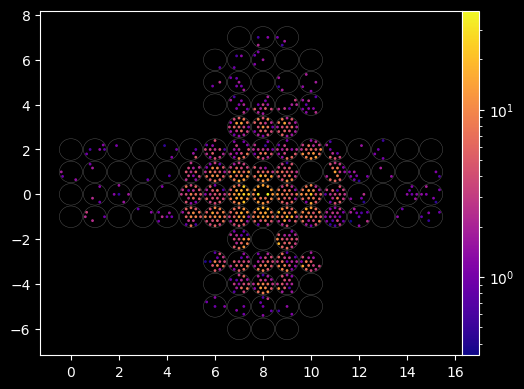

(2014,)


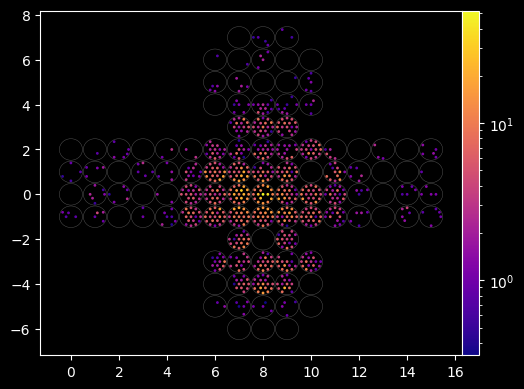

(2014,)


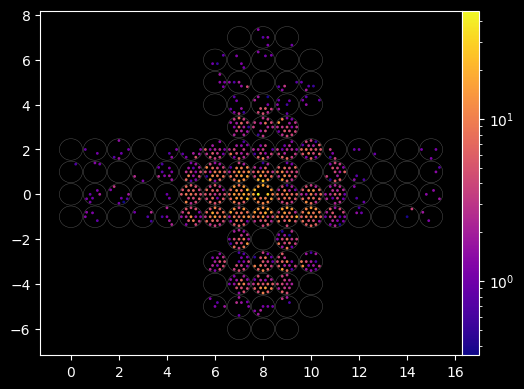

(2014,)


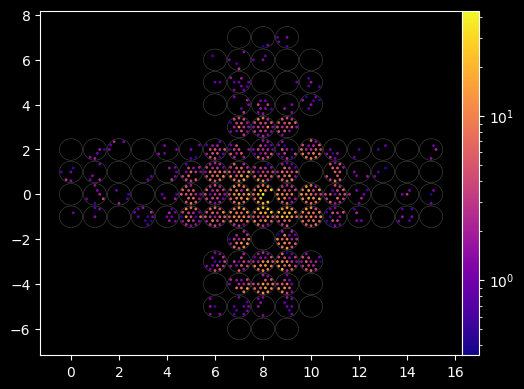

(2014,)


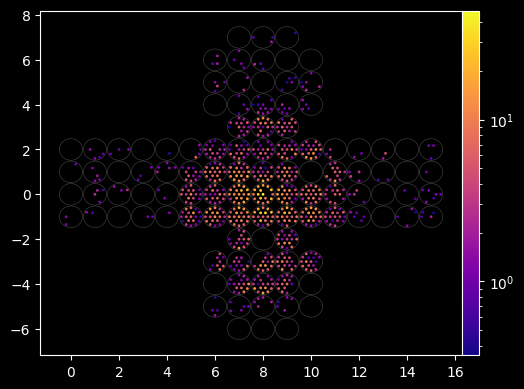

(2014,)


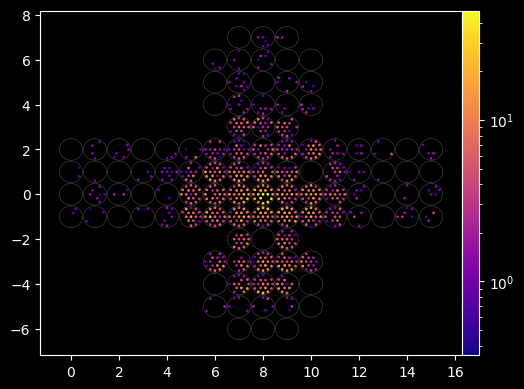

(2014,)


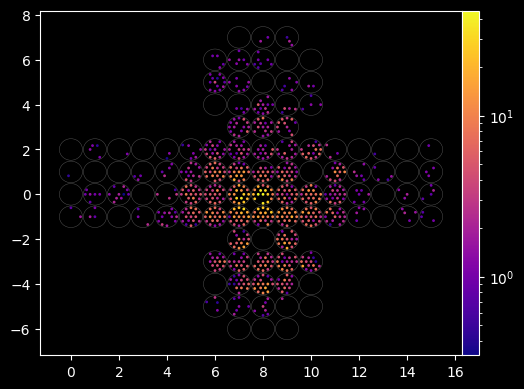

(2014,)


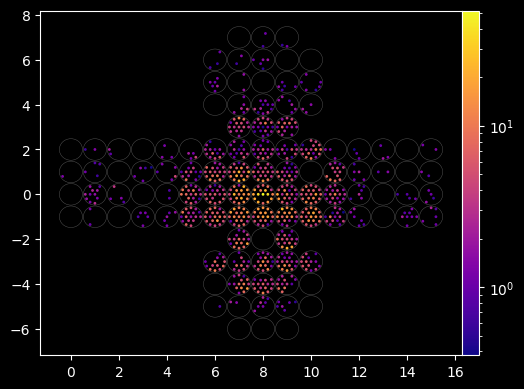

(2014,)


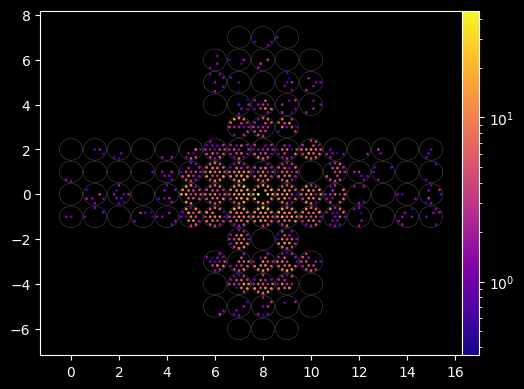

(2014,)


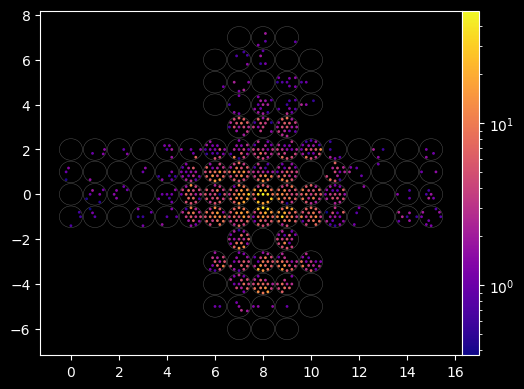

(2014,)


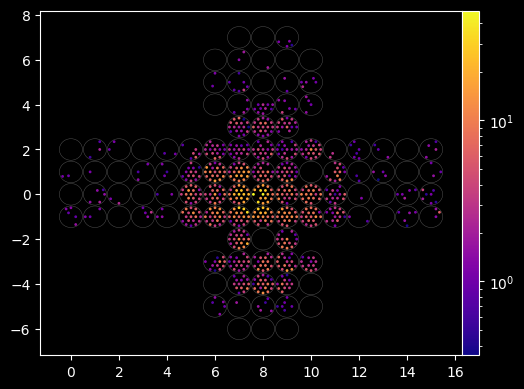

(2014,)


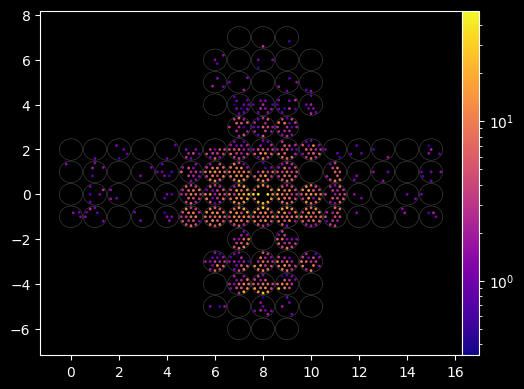

(2014,)


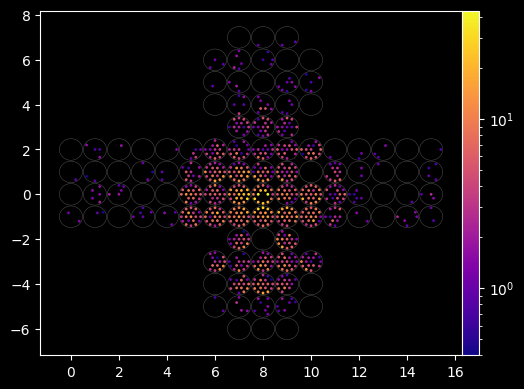

(2014,)


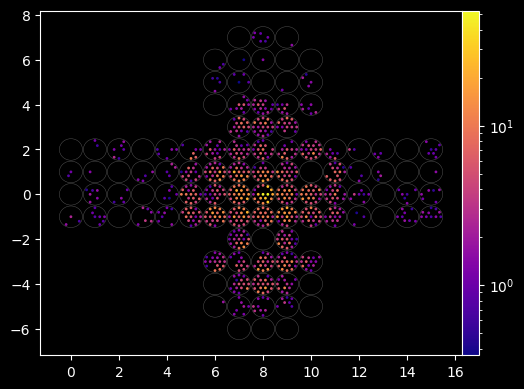

(2014,)


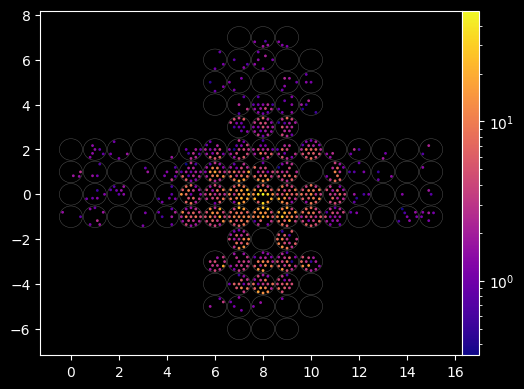

(2014,)


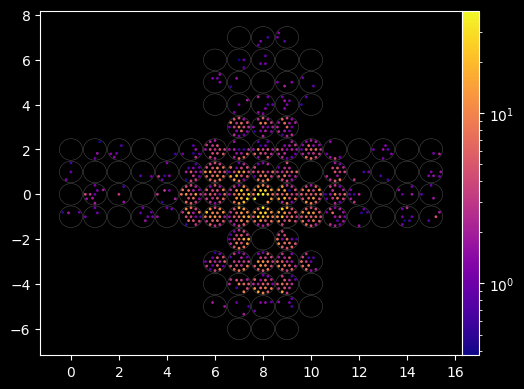

(2014,)


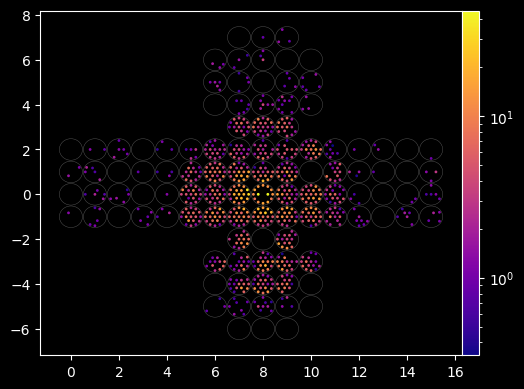

(2014,)


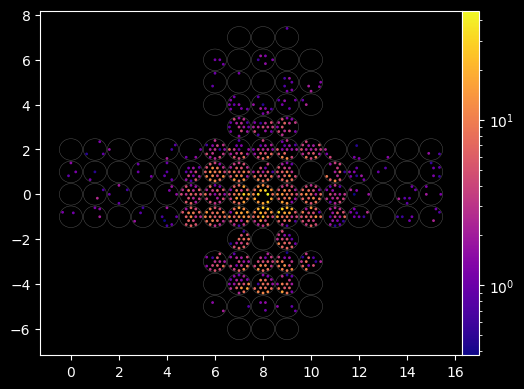

(2014,)


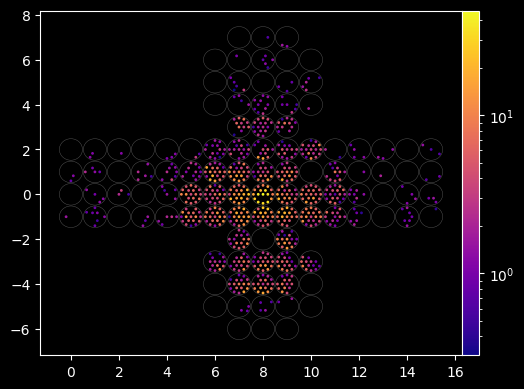

(2014,)


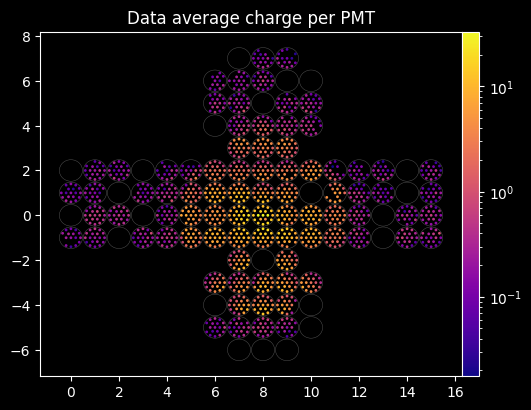

(2014,)


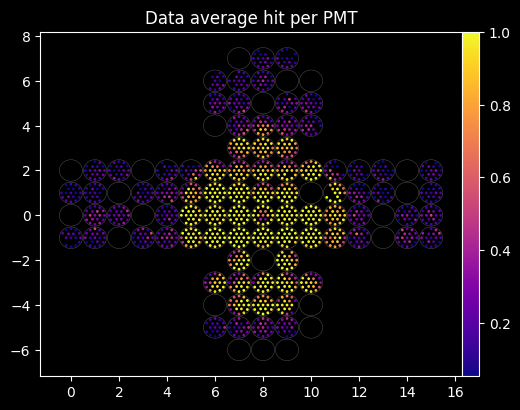

In [ ]:
#For data
eventDisplay = EventDisplay() 
#load the positions of the mPMTs (an internal file to the event display class that 
#specificies where to plot and what orientation to plot mPMTs on the event display)
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
nEvents = 0 
pmt_slot = []
pmt_pos = []
data_to_plot = []
#1567 1500-1800
#1848 2000-3000
#1610 1500-1800
tr=[1500,1800]
avg_charge_data=np.zeros(2014) #Number of PMTs in WCTE
avg_hit_data=np.zeros(2014)
avg_hit=[] #
avg_total_charge=[] #
for event in all_proton_events:
    if (event['window_data_quality']!=0):
        #print("Event excluded with flag",event['window_data_quality'])
        continue
    #filter out windows which fail the data quality checks 
    pre_hit_mask = (event['hit_pmt_readout_mask']==0) & (event['hit_mpmt_card_ids']<120) & (event['hit_pmt_calibrated_times']>tr[0]) & (event['hit_pmt_calibrated_times']<tr[1])

    values,edges = np.histogram(event['hit_pmt_calibrated_times'][pre_hit_mask],bins=np.arange(tr[0],tr[1],1))
    peak_time = edges[np.argmax(values)]
    min_time = peak_time - 20
    max_time = peak_time + 20
    #print(min_time,max_time)
    #apply a mask to hits, don't include hits labelled as bad or hits on trigger mainboards in the event display
    hit_mask = (event['hit_pmt_readout_mask']==0) & (event['hit_mpmt_card_ids']<120) & (event['hit_pmt_calibrated_times']>min_time) & (event['hit_pmt_calibrated_times']<max_time)
    nEvents+=1
    #pmt_slot.extend(event['hit_mpmt_slot_ids'][hit_mask])
    pmt_slot=event['hit_mpmt_slot_ids'][hit_mask]
    pmt_pos=event['hit_pmt_position_ids'][hit_mask]
    data_to_plot=event['hit_pmt_charges'][hit_mask]
                                        
    #pmt_pos.extend(event['hit_pmt_position_ids'][hit_mask])
    #data_to_plot.extend(event['hit_pmt_charges'][hit_mask])
    ev_disp_data = eventDisplay.process_data(pmt_slot,pmt_pos,data_to_plot,sum_data=True)
    avg_charge_data+=ev_disp_data
    #eventDisplay.plotEventDisplay(ev_disp_data/135,color_norm=colors.LogNorm(), style= "dark_background")
    #plt.show(block=False)
    hit_array = (data_to_plot> 0)
    ev_disp_data = eventDisplay.process_data(pmt_slot,pmt_pos,hit_array,sum_data=True)
    avg_hit_data+=ev_disp_data
    avg_hit.append(len(data_to_plot))
    avg_total_charge.append(np.sum(data_to_plot/135))
    
#average by each event
#ev_disp_data = ev_disp_data/nEvents
total_charge_data= (avg_charge_data/(nEvents*135))
total_hit_data= (avg_hit_data/(nEvents))
eventDisplay.plotEventDisplay(total_charge_data,color_norm=colors.LogNorm(), style= "dark_background")
plt.title("Data average charge per PMT")
plt.show(block=False)
plt.style.use('default')
eventDisplay.plotEventDisplay(total_hit_data,color_norm=colors.Normalize(),  style= "dark_background")
plt.title("Data average hit per PMT")
plt.show(block=False)
#plt.style.use('default')

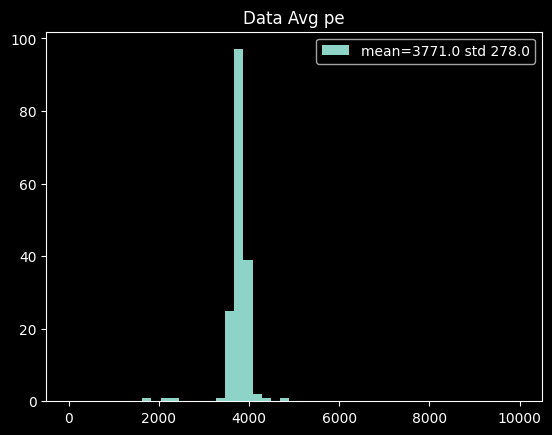

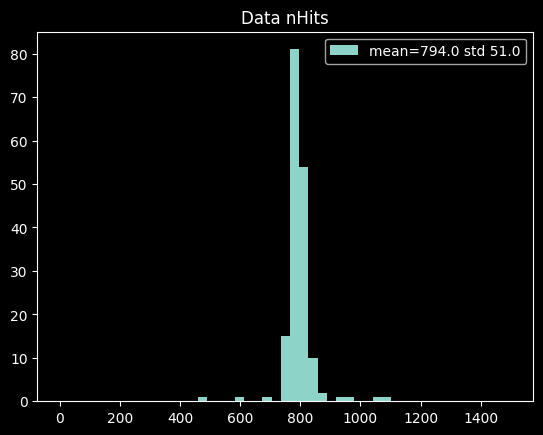

In [7]:
#avg_charge_data=total_charge_data/(nEvents*135)
#mask_zero=avg_charge_data>0.1
plt.hist(avg_total_charge,bins=np.linspace(0,10000),label="mean="+str(np.round(np.mean(avg_total_charge)))+" std "+str(np.round(np.std(avg_total_charge))))
plt.title("Data Avg pe")
plt.legend()
plt.show()
plt.hist(avg_hit,bins=np.linspace(0,1500),label="mean="+str(np.round(np.mean(avg_hit)))+" std "+str(np.round(np.std(avg_hit))))
plt.title("Data nHits")
plt.legend()


In [23]:
#filename="/eos/user/v/vgousyle/wcte_test/example/wcsim/wcsim_final3.h5"
import uproot
#file_path="/eos/user/v/vgousyle/wcte_test/muon_event_mdt.root"
file_path="/eos/user/v/vgousyle/wc_sim_build/proton_final_mdt.root"
with uproot.open(file_path) as root_file:
    tree = root_file["WCTEReadoutWindows"]
    branches_to_load = ["window_time"]
    all_events_mc = tree.arrays(entry_start=0,entry_stop=200,library="ak")    


#with h5py.File(filename, "r") as f:
#    print("Top-level keys:")
#    print(list(f.keys())) # groups/datasets at root level
#    print(f['pmtQ'])

    # Walk through everything in the file
# print(data.shape, data.dtype)

In [24]:
#apply filter on Simulation 
filtered_charge=[]
channel_mask=np.zeros(len(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])))
for mpmt in np.unique(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])):
    if mpmt not in good_mpmt:
        continue 
    #hit_mpmt_slot_ids
    #print(mpmt)
    try:
        #print(bad_pmt_channels[mpmt])
        index=np.where(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])==mpmt) #All the channels
        #index_2=np.where(np.concatenate(event_mc['hit_pmt_position_ids'])[index]
        
        test_pmt=np.concatenate(all_events_mc['hit_pmt_position_ids'])[index] 
        mask = ~np.isin(bad_pmt_channels[mpmt], test_pmt)
        channel_mask[index][mask]=True
        #for i in range(0,len(bad_pmt_channels[mpmt])):
        #    channel_mask[index]=True
    except:
        index=np.where(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])==mpmt)
        channel_mask[index]=True
lengths = [len(x) for x in all_events_mc['hit_mpmt_slot_ids']]
rebuilt_mask=np.split(channel_mask, np.cumsum(lengths)[:-1])
rebuilt_mask = [x.tolist() for x in rebuilt_mask]

(2014,)


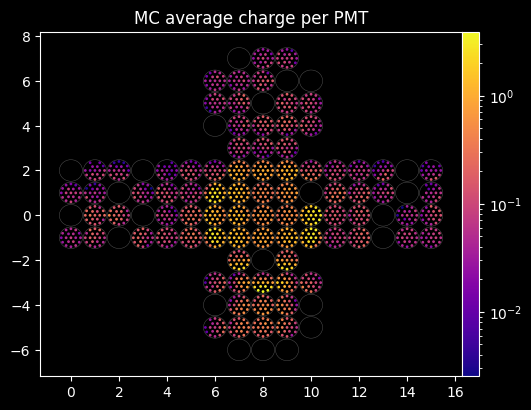

In [25]:
import importlib
import WCTE_event_display.EventDisplay
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

importlib.reload(WCTE_event_display.EventDisplay)

from WCTE_event_display.EventDisplay import EventDisplay

#create an instance of event diplay class
eventDisplay = EventDisplay() 
#load the positions of the mPMTs (an internal file to the event display class that 
#specificies where to plot and what orientation to plot mPMTs on the event display)
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
#e.g. select a single event randomly
total_charge_mc=np.zeros(2014)
nevents=0
avg_hit_mc=[]
avg_charge_mc=[]
for i in range(0,len(all_events_mc)):
        nevents+=1
    #print(all_events_beam["is_muon"][i])
        event_mc=all_events_mc[i]
        values,edges = np.histogram(event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)],bins=np.arange(0,50,1))
        peak_time = edges[np.argmax(values)]
        #print(peak_time)
        min_time = peak_time - 8
        max_time = peak_time + 4
        #print(min_time,max_time)
        pre_hit_mask =(event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)]>min_time) & (event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)]<max_time)
        #plt.hist(event_mc['hit_pmt_times'],bins=np.linspace(5,50,100))
        #plt.show()
        #pre_hit_mask =  (event_mc['hit_pmt_times']<20)
        pmt_slot = event_mc['hit_mpmt_slot_ids'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]
        pmt_pos = event_mc['hit_pmt_position_ids'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]
        mc_to_plot  = event_mc['hit_pmt_charges'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]

        #this function processes pmt positions and the data to plot into an array for use by the event display
        #sum_data will sum data for the same channel e.g. if a channel has 2 hits in event['hit_pmt_charges'] they will be summed
        #if summed data is false it will by default take the smallest value for each channel for plotting time distributions
        avg_hit_mc.append(len(mc_to_plot))
        ev_disp_mc = eventDisplay.process_data(pmt_slot,pmt_pos,mc_to_plot,sum_data=True)
        total_charge_mc+=ev_disp_mc
        avg_charge_mc.append(np.sum(mc_to_plot))
        #print(ev_disp_mc)
        #this pltos the event display, colors.Normalize() will plot on a linear scale
        #eventDisplay.plotEventDisplay(ev_disp_mc,color_norm=colors.LogNorm(), style= "dark_background")

        #optional ability to draw the mPMT slot id for each mPMT
        # eventDisplay.label_mPMTs(np.arange(0,106))
        #fig = plt.gcf()  
        #plt.show()
        #pdf_global.savefig(fig)
        #plt.close() 

        #plt.show(block=False)
        #plt.style.use('default') 
        #plt.hist(all_events[i]['hit_pmt_calibrated_times'][hit_mask],bins=np.linspace(428,440,100))
        #plt.yscale("log")   
        #plt.show()
eventDisplay.plotEventDisplay(total_charge_mc/nevents,color_norm=colors.LogNorm(), style= "dark_background")

#optional ability to draw the mPMT slot id for each mPMT
# eventDisplay.label_mPMTs(np.arange(0,106))
#fig = plt.gcf()  
plt.title("MC average charge per PMT")
plt.show()

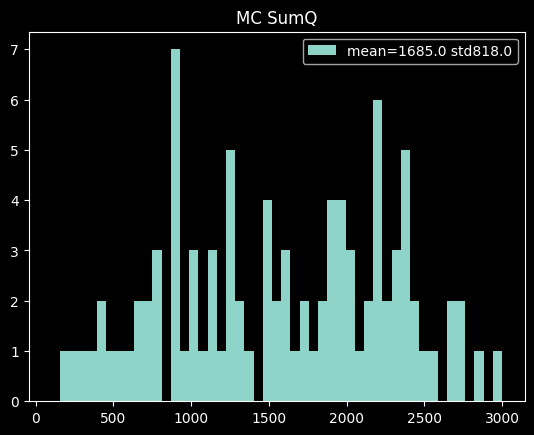

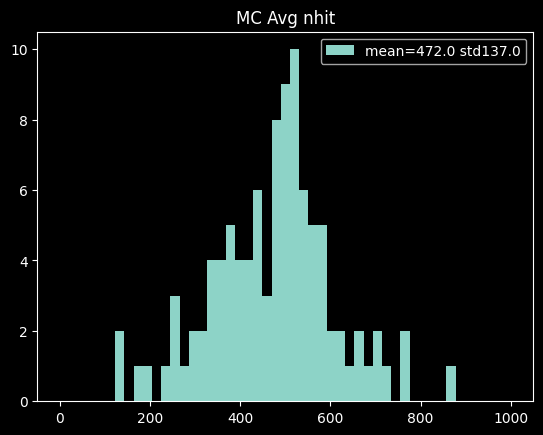

In [32]:
#avg_charge_mc=(total_charge_mc/nevents)
#mask_zero=avg_charge_mc>0.1

plt.hist(avg_charge_mc,bins=np.linspace(100,3000,50),label="mean="+str(np.round(np.mean(avg_charge_mc)))+" std"+str(np.round(np.std(avg_charge_mc))))
plt.title("MC SumQ")
plt.legend()
plt.show()
plt.hist(avg_hit_mc,bins=np.linspace(0,1000),label="mean="+str(np.round(np.mean(avg_hit_mc)))+" std"+str(np.round(np.std(avg_hit_mc))))
plt.title("MC Avg nhit")
plt.legend()
plt.show()

/tmp/vgousyle/ipykernel_2601793/2335863469.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio_mc=total_charge_data/(total_charge_mc/nevents)


(2014,)


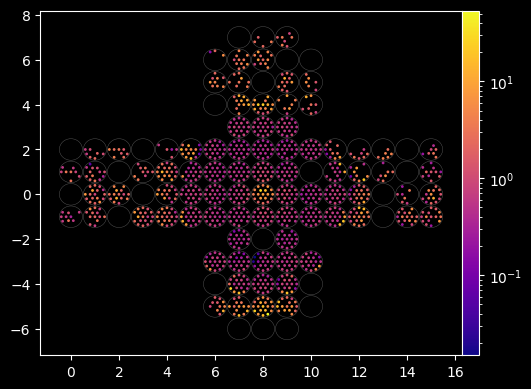

In [91]:
ratio_mc=total_charge_data/(total_charge_mc/nevents)
eventDisplay.plotEventDisplay(ratio_mc,color_norm=colors.LogNorm(), style= "dark_background")
plt.show(block=False)
plt.style.use('default')

In [ ]:
mask_zero=ratio_mc[np.isfinite(ratio_mc)]>3
np.mean(ratio_mc[np.isfinite(ratio_mc)][mask_zero])


np.float64(7.169250720944458)

(0.0, 3.0)

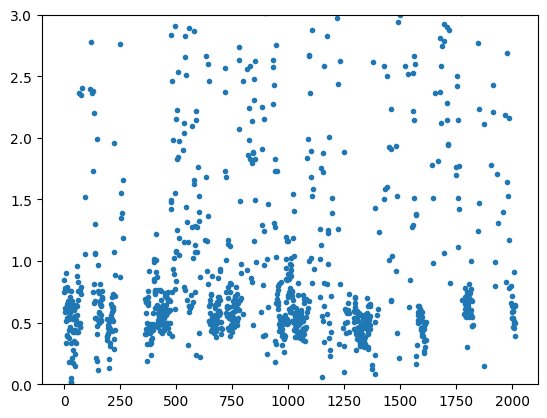

In [109]:
plt.plot(ratio_mc,'.')
plt.ylim(0,3)

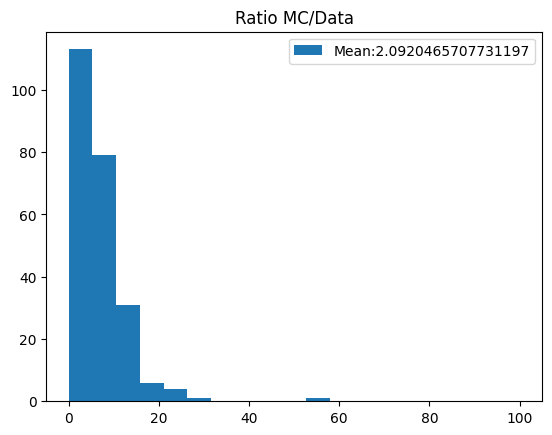

In [106]:
plt.hist(ratio_mc[np.isfinite(ratio_mc)][mask_zero],bins=np.linspace(0,100,20),label="Mean:"+str(np.mean(ratio_mc[np.isfinite(ratio_mc)])))
plt.title("Ratio MC/Data")
plt.legend()

(2014,)


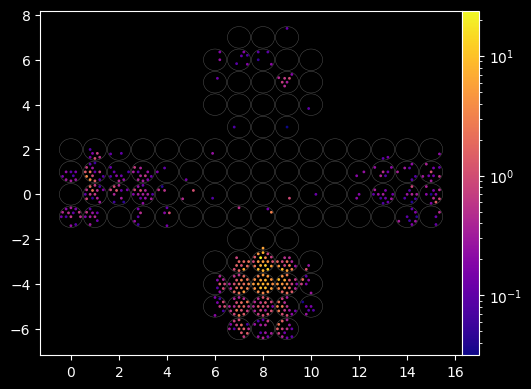

In [40]:
#For MC
nEvents = 0 
pmt_slot = []
pmt_pos = []
mc_to_plot = []

for event_mc in all_events_mc[:100]:
    #filter out windows which fail the data quality checks 
    nEvents+=1
    #event=all_events_mc[i]
    pre_hit_mask =  (event_mc['hit_pmt_times']<10)
    pmt_slot.extend(event_mc['hit_mpmt_slot_ids'][pre_hit_mask])
    pmt_pos.extend(event_mc['hit_pmt_position_ids'][pre_hit_mask])
    mc_to_plot.extend(event_mc['hit_pmt_charges'][pre_hit_mask])

ev_disp_mc = eventDisplay.process_data(pmt_slot,pmt_pos,mc_to_plot,sum_data=True)
#average by each event
ev_disp_mc = ev_disp_mc/nEvents 
eventDisplay.plotEventDisplay(ev_disp_mc,color_norm=colors.LogNorm(), style= "dark_background")
plt.show(block=False)
plt.style.use('default')

In [19]:
n_pmts=1566
avg_charge=np.zeros((len(good_mpmt),19))
for e in range(3,4):
    for i in range(1,len(good_mpmt)):
        mpmt_id=np.where(all_events_mc['hit_mpmt_slot_ids'][e]==good_mpmt[i])
        #print("This is mPMT",good_mpmt[i])
        for j in range(0,19):
            
            test = bad_pmt_channels.get(good_mpmt[i])
            #print(test)
            if np.any(test==j):
                print(good_mpmt[i])
            pmt_id=np.where(all_events_mc['hit_pmt_position_ids'][e][mpmt_id]==j)
            #print(pmt_id,j)
            if len(pmt_id[0])==0:
                continue
            #bad_pmt_channels.update({good_mpmt[i]:complete_mpmt[mask]})
            avg_charge[i][j]+=all_events_mc['hit_pmt_charges'][e][mpmt_id][pmt_id][0]



4
20
36
40
49
57
66
66
66
66
84


In [25]:
k=np.ones((len(good_mpmt)-1,19),dtype=int)
k2=np.ones((len(good_mpmt)-1,19),dtype=int)
print(k)

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


In [26]:
pmt_pos_ar=k2* np.arange(19)
pmt_slot_ar=k* good_mpmt[1:, None]

In [28]:
slot_test=np.concatenate(pmt_slot_ar).tolist()

In [30]:
np.min(slot_test)

np.int64(0)

In [32]:
np.max(all_events_mc['hit_mpmt_slot_ids'][e])

np.int32(105)

(2014,)


ValueError: 'c' argument has 1596 elements, which is inconsistent with 'x' and 'y' with size 2014.

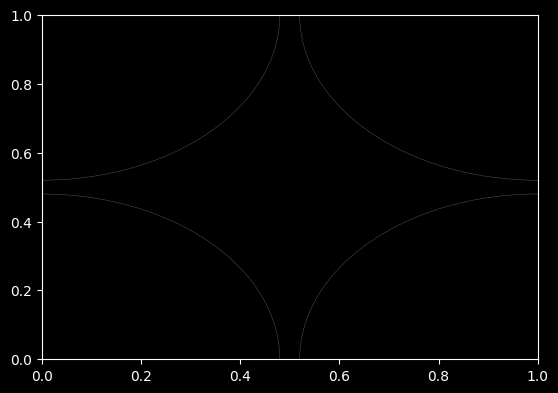

In [ ]:
eventDisplay = EventDisplay() 
#load the positions of the mPMTs (an internal file to the event display class that 
#specificies where to plot and what orientation to plot mPMTs on the event display)
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
#e.g. select a single event randomly
for i in range(2,3):
    #print(all_events_beam["is_muon"][i])
        #event_mc=all_events_mc[i]
        #values,edges = np.histogram(event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)],bins=np.arange(0,50,1))
        #peak_time = edges[np.argmax(values)]
        #print(peak_time)
        #min_time = peak_time - 8
        #max_time = peak_time + 4
        #print(min_time,max_time)
        #pre_hit_mask =(event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)]>min_time) & (event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)]<max_time)
        #plt.hist(event_mc['hit_pmt_times'],bins=np.linspace(5,50,100))
        #plt.show()
        #pre_hit_mask =  (event_mc['hit_pmt_times']<20)
        pmt_slot=np.concatenate(pmt_slot_ar).tolist()#list(np.concatenate(pmt_slot_ar))#pmt_slot_ar
        pmt_pos=np.concatenate(pmt_pos_ar).tolist()#list(np.concatenate(pmt_pos_ar))#pmt_pos_ar
        mc_to_plot=np.concatenate(avg_charge).tolist()#avg_charge
        #pmt_slot = event_mc['hit_mpmt_slot_ids'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]
        #pmt_pos = event_mc['hit_pmt_position_ids'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]
        #mc_to_plot  = event_mc['hit_pmt_charges'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]
        #mc_to_plot[0]=np.nan
        #this function processes pmt positions and the data to plot into an array for use by the event display
        #sum_data will sum data for the same channel e.g. if a channel has 2 hits in event['hit_pmt_charges'] they will be summed
        #if summed data is false it will by default take the smallest value for each channel for plotting time distributions
        ev_disp_mc = eventDisplay.process_data(pmt_slot,pmt_pos,mc_to_plot,sum_data=True)

        #this pltos the event display, colors.Normalize() will plot on a linear scale
        eventDisplay.plotEventDisplay(mc_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

        #optional ability to draw the mPMT slot id for each mPMT
        # eventDisplay.label_mPMTs(np.arange(0,106))
        #fig = plt.gcf()  
        plt.show()

(array([8.666e+03, 4.000e+00, 2.590e+02, 3.000e+00, 0.000e+00, 4.000e+00,
        1.000e+00, 3.000e+00, 1.570e+02, 2.000e+00, 1.000e+00, 2.000e+00,
        2.000e+00, 7.000e+00, 4.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        2.500e+02, 1.000e+01, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 8.000e+00, 2.000e+00, 2.000e+00,
        2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

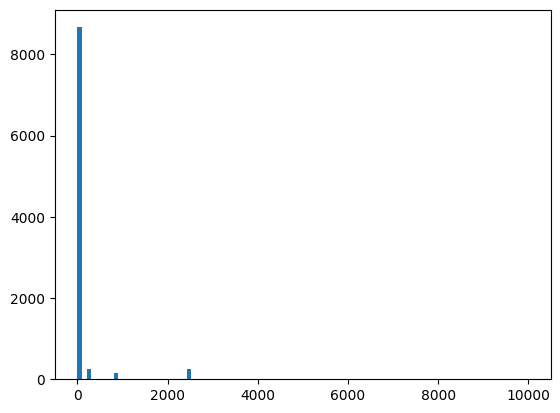

In [35]:
plt.hist(np.concatenate(all_events_mc['hit_pmt_times']),bins=np.linspace(0,10000,100))


In [37]:
j=np.where(np.concatenate(all_events_mc['hit_pmt_times'])>5000)
np.concatenate(all_events_mc['hit_pmt_times'])[j]

<Array [4.34e+09, 3.66e+05, ..., 3.64e+05, 3.64e+05] type='700 * float32'>

(2014,)


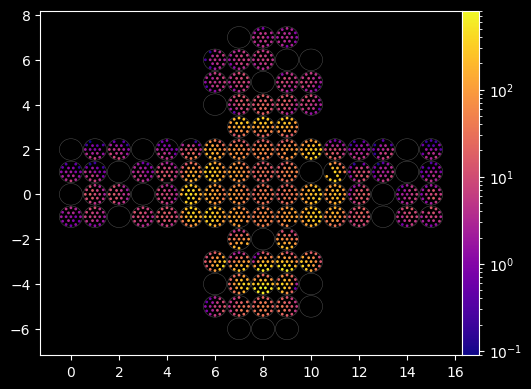

In [71]:
ratio_mc=(total_charge_data/nEvents)/(total_charge/10)

/tmp/vgousyle/ipykernel_2986005/1647675533.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio_mc=(total_charge_data/nEvents)/(total_charge/10)
/tmp/vgousyle/ipykernel_2986005/1647675533.py:1: RuntimeWarning: invalid value encountered in divide
  ratio_mc=(total_charge_data/nEvents)/(total_charge/10)


(2014,)


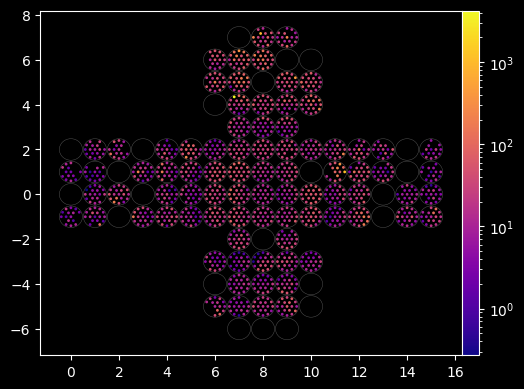

In [73]:
ratio_mc
eventDisplay.plotEventDisplay(ratio_mc,color_norm=colors.LogNorm(), style= "dark_background")
plt.show(block=False)
plt.style.use('default')

In [46]:
ev_disp_ratio = eventDisplay.process_data(pmt_slot,pmt_pos,np.array(data_to_plot)/np.array(mc_to_plot),sum_data=True)
#average by each event
ev_disp_ratio = ev_disp_data/ev_disp_mc
eventDisplay.plotEventDisplay(ev_disp_data,color_norm=colors.LogNorm(), style= "dark_background")
plt.show(block=False)
plt.style.use('default')

ValueError: operands could not be broadcast together with shapes (0,) (10139,) 

In [50]:
np.array(data_to_plot)

array([124., 118., 122., ..., 205., 134., 217.],
      shape=(23331,), dtype=float32)

In [28]:
f['PMT_slot_id'][0:20]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19,  1])

In [29]:
f['mPMT_slot'][0:20]

array([37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37,
       37, 37, 38])

In [18]:
len(f['mPMT_slot'])

1843

In [13]:
import matplotlib.pyplot as plt
mask=np.where(f['pmtQ'][0]>5)
plt.hist(f['pmtQ'][0][mask],bins=np.linspace(0,100,30))

NameError: name 'np' is not defined

In [29]:
mask=np.where(f['pmtQ'][0]>25)

(2014,)


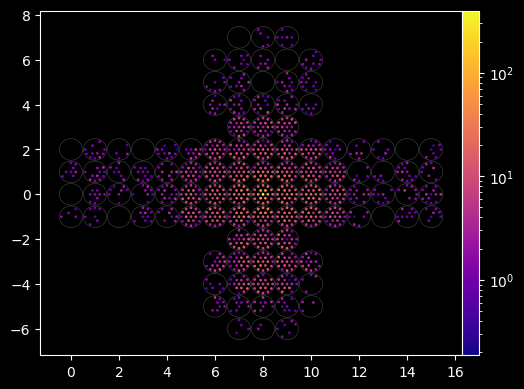

(2014,)


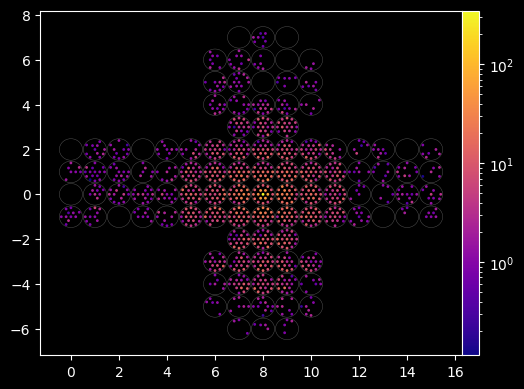

In [35]:
import importlib
import WCTE_event_display.EventDisplay
from matplotlib.backends.backend_pdf import PdfPages

importlib.reload(WCTE_event_display.EventDisplay)

from WCTE_event_display.EventDisplay import EventDisplay

#create an instance of event diplay class
eventDisplay = EventDisplay() 
#load the positions of the mPMTs (an internal file to the event display class that 
#specificies where to plot and what orientation to plot mPMTs on the event display)
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
#pdf_global = PdfPages(f"/eos/user/v/vgousyle/proton_search/analysis_tools/notebooks/plots/proton_ring.pdf")
#e.g. select a single event randomly
for i in range(0,2):
    #print(all_events_beam["is_muon"][i]
      
        data_to_plot  = f['pmtQ'][i]
        pmt_slot=f['mPMT_slot']
        pmt_pos=np.array(f['PMT_slot_id'])-1
        #pmt_slot = event['hit_mpmt_slot_ids'][hit_mask]
        #pmt_pos = event['hit_pmt_position_ids'][hit_mask]

        #this function processes pmt positions and the data to plot into an array for use by the event display
        #sum_data will sum data for the same channel e.g. if a channel has 2 hits in event['hit_pmt_charges'] they will be summed
        #if summed data is false it will by default take the smallest value for each channel for plotting time distributions
        ev_disp_data = eventDisplay.process_data(pmt_slot,pmt_pos,data_to_plot,sum_data=True)

        #this pltos the event display, colors.Normalize() will plot on a linear scale
        eventDisplay.plotEventDisplay(ev_disp_data,color_norm=colors.LogNorm(), style= "dark_background")

        #optional ability to draw the mPMT slot id for each mPMT
        # eventDisplay.label_mPMTs(np.arange(0,106))
        fig = plt.gcf()  
        #pdf_global.savefig(fig)
        

        #plt.show(block=False)
        #plt.style.use('default') 
        #plt.hist(all_events[i]['hit_pmt_calibrated_times'][hit_mask],bins=np.linspace(428,440,100))
        #plt.yscale("log")   
        plt.show()





In [34]:
np.min(np.array(f['PMT_slot_id'])-1)

np.int64(0)